# Multimodal Cancer Classification Challenge 2026 — v46 (soft pseudo-labels / Hinton 2015 distillation)

**v46 = stripped v44 + soft pseudo-labels from v44.** The single most informative change vs v44: instead of hardening v44's predictions to 0/1 at a 0.05/0.95 threshold (which uses only ~9k cells), v46 uses **v44's raw probabilities as BCE targets for all 59k test cells**. This is Hinton 2015 knowledge distillation applied to our pseudo-label pipeline.

## What v46 changes vs v44

| Component | v44 | **v46 (this)** |
|---|---|---|
| Pseudo teacher | v41 (LB 0.7563) | **v44 (LB 0.7812)** — noisy-student iteration |
| Pseudo target | Hardened 0 or 1 at 0.05/0.95 threshold | **Raw probability** (e.g. p=0.78 → BCE target = 0.78) |
| Pseudo set size | ~9k cells (16% of test) | **~59k cells (100% of test)** — 6× more training signal |
| Pseudo loss weight | 1.0 (same as real) | **0.5** — conservatively down-weight |
| `USE_FL_TUNED_AUG` | `True` | **`False`** — reverted (suspect from v43 regression) |
| `WEIGHT_DECAY` | 3e-4 | **1e-4** — reverted to v41's value |

Everything else identical to v44: 3 seeds × SWA(last 4 ep) + label smoothing 0.05 (real cells only — soft pseudos don't get smoothed) + dropout 0.4 + paired RandomResizedCrop + 40-way TTA + MIL + AdaBN + test stain norm.

## Why soft pseudos should beat hard pseudos

Hard pseudo throws away v44's confidence information. A cell at p=0.78 gets forced to "positive" with the same weight as a cell at p=0.99 — but they're not equally informative. Cells at p=0.78 carry useful uncertainty signal that the student should learn from.

Hinton 2015 calls the preserved confidence the **"dark knowledge"** of the teacher. On ImageNet, distillation typically gains +0.5 to +1.5 pp F1 over hard pseudos with the same teacher. The conditions for distillation to help match our setup: (a) the teacher is well-calibrated (v44's 40-way TTA averages probabilities cleanly), and (b) the student has spare capacity to absorb the extra signal (we have 4M params on 124k effective cells — not saturated).

Math: v44's hard pseudo with 9.3k cells → +0.025 LB. Soft pseudo uses 6× more cells with richer per-cell signal. Even if marginal returns diminish, +0.005 to +0.015 over v44 is reasonable.

## Loss function details

For each cell in the batch:

- **Real cell** (patient_id ≥ 0): BCE against smoothed hard label (current v44 behavior).
  ```
  target = label * (1 - 0.05) + 0.05 * 0.5
  loss_per_cell = BCE_with_logits(logit, target, pos_weight)
  ```
- **Soft pseudo cell** (patient_id = -1): BCE against raw v44 probability, weighted down.
  ```
  target = v44_prob  # e.g., 0.78
  loss_per_cell = 0.5 * BCE_with_logits(logit, target, pos_weight)
  ```
- **MIL aux loss**: still skips pseudo cells (patient_id == -1 filtered out), unchanged from v44.

The 0.5 down-weight on pseudo cells is a safety margin: if v44 has systematic biases, the real labels still dominate the gradient.

## Required Kaggle inputs

Attach both to v46 on Kaggle:
1. `rafaelproena/a3-adl` (competition data)
2. **`rafaelproena/submissionv44`** — **upload v44's `submission.csv` as a new private Kaggle dataset named `submissionv44`** (same one v45 uses).

Path candidates tried in order:

```
/kaggle/input/datasets/rafaelproena/submissionv44/submission.csv
/kaggle/input/submissionv44/submission.csv
/kaggle/input/v44-predictions/submission.csv
```

## Expected lift

| Run | LB |
|---|---|
| v41 | 0.7563 |
| **v44 (hard pseudo from v41)** | **0.7812** ← current best |
| v45 (hard pseudo from v44, stripped) | (queued) |
| v46 (soft pseudo from v44, stripped, this) | **~0.79–0.80 expected** |
| LB leader (current) | 0.7832 |

P(v46 > v44 standalone): ~60%. P(v46 > leader 0.7832): ~55%. v46 and v45 test orthogonal hypotheses (soft vs noisy-student-with-hard), so they should NOT be ensembled — pick the winner.

## Compute on T4

~5–5.5h: the soft-pseudo training set is 173k cells (vs v44's 124k), so each epoch is ~25% longer.

## Sanity check before the 5-hour commit

When cell 5 finishes, the log should show roughly:

```
Pseudo-labels loaded from .../submissionv44/submission.csv  [mode: SOFT]
  kept 59040 cells (all of test) | mean soft target: 0.4266
  Combined training set: 173342 cells (114302 real + 59040 pseudo)
```

If it falls back to no-pseudo or warns, fix the attached dataset **before** letting the run go.


In [1]:
import os
os.environ["PYTHONUNBUFFERED"] = "1"

import re, io, json, time, random, glob, functools, gc
from pathlib import Path

print = functools.partial(print, flush=True)

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim.swa_utils as swa_utils
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader, Sampler
from torchvision import models
from sklearn.metrics import roc_auc_score
from PIL import Image
import matplotlib.pyplot as plt

print("torch:", torch.__version__, "cuda:", torch.cuda.is_available(),
      "n_gpu:", torch.cuda.device_count())
!nvidia-smi -L

torch: 2.10.0+cu128 cuda: True n_gpu: 2
GPU 0: Tesla T4 (UUID: GPU-0b5699c6-aa9e-c5f5-308b-6635d315c6d8)
GPU 1: Tesla T4 (UUID: GPU-619db327-b1ff-ab89-16cf-3a82162f9cbe)


In [2]:
DATA_ROOT_CANDIDATES = [
    Path("/kaggle/input/datasets/rafaelproena/a3-adl"),
    Path("/kaggle/input/a3-adl"),
    Path("/kaggle/input/competitions/multimodal-cancer-classification-challenge-2026"),
]
DATA_ROOT = next((p for p in DATA_ROOT_CANDIDATES if (p / "train.csv").exists()), None)
assert DATA_ROOT is not None, f"train.csv not found at any of {DATA_ROOT_CANDIDATES}"
print("DATA_ROOT =", DATA_ROOT)

OUT_DIR = Path("/kaggle/working/runs")
OUT_DIR.mkdir(parents=True, exist_ok=True)
WORK_DIR = Path("/kaggle/working")

# === v19 structural choices (kept) ===
USE_EFFICIENTNET    = True
USE_MIL_LOSS        = True
MIL_WEIGHT          = 0.5
USE_STRONG_AUG      = True
RANDOM_ERASING_P    = 0.25

USE_TEST_STAIN_NORM = True
USE_ADABN           = True

# === v41 changes (kept) ===
LABEL_SMOOTHING     = 0.05
DROPOUT             = 0.4
USE_PAIRED_CROP     = True
PAIRED_CROP_SCALE   = (0.85, 1.0)

# === v43-introduced features (kept from v44) ===
SEEDS               = [1, 2, 3]                  # multi-seed ensemble
SWA_EPOCHS          = 4                          # SWA over last 4 epochs of each seed
USE_EXTENDED_TTA    = True
TTA_SCALES          = (96, 112, 128, 144, 160)   # 5 scales x 8 D4 = 40-way

# === v46 STRIPPED: revert v43's FL-tuned aug + WD bump (same rationale as v45) ===
USE_FL_TUNED_AUG    = False                      # v44 True; v46 REVERTS to v41
FL_COLORJITTER_B    = 0.5
FL_COLORJITTER_C    = 0.3
FL_GAMMA_LO         = 0.85
FL_GAMMA_HI         = 1.15
FL_GAMMA_P          = 0.5

# === v46 NEW: soft pseudo-labels from v44 (Hinton 2015 distillation) ===
# Use v44's raw probabilities (not hardened) as BCE targets for ALL test cells.
# Preserves "dark knowledge" — confidence info that hard pseudo throws away.
# Loss weight 0.5 protects against v44 systematic biases.
USE_PSEUDO_LABELS    = True
USE_SOFT_PSEUDO      = True                      # v46 NEW: soft vs hard pseudo
PSEUDO_LOSS_WEIGHT   = 0.5                       # down-weight pseudo BCE vs real BCE
USE_PSEUDO_BAND_FILTER = False                   # optional: drop uncertain band [BAND_LO, BAND_HI]
PSEUDO_BAND_LO       = 0.4
PSEUDO_BAND_HI       = 0.6
# Hard-pseudo thresholds kept as fallback (used only if USE_SOFT_PSEUDO=False)
PSEUDO_THRESH_LOW    = 0.05
PSEUDO_THRESH_HIGH   = 0.95

_PSEUDO_LABEL_CANDIDATES = [
    "/kaggle/input/datasets/rafaelproena/v44seed1/submission_seed1.csv",
    "/kaggle/input/datasets/rafaelproena/v44seed1/submission.csv",
    "/kaggle/input/v44seed1/submission_seed1.csv",
    "/kaggle/input/v44seed1/submission.csv",
    "/kaggle/input/datasets/rafaelproena/submissionv44/submission.csv",
    "/kaggle/input/submissionv44/submission.csv",
    "/kaggle/input/v44-predictions/submission.csv",
]

PSEUDO_LABEL_CSV = next(
    (p for p in _PSEUDO_LABEL_CANDIDATES if Path(p).exists()),
    _PSEUDO_LABEL_CANDIDATES[0],  # default to first; load step will warn if missing
)

# === Training (mostly v41) ===
EPOCHS      = 12
BATCH_SIZE  = 128
LR          = 3e-4
WEIGHT_DECAY = 1e-4    # v46: REVERTED from v44's 3e-4 to v41's 1e-4
GRAD_CLIP   = 1.0
MIXUP_ALPHA = 0.0

NUM_WORKERS = 2
PATIENTS_PER_BATCH = 4

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if torch.cuda.is_available():
    torch.cuda.set_device(0)

BF_MEAN, BF_STD = 0.504, 0.216
FL_MEAN, FL_STD = 0.100, 0.144

def seed_everything(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

seed_everything(SEEDS[0])

print(f"\nConfig (v46 - stripped + SOFT pseudo from v44 / Hinton distillation):")
print(f"  SEEDS                = {SEEDS}  (multi-seed ensemble)")
print(f"  SWA_EPOCHS           = {SWA_EPOCHS}  (average last {SWA_EPOCHS} epochs per seed)")
print(f"  USE_FL_TUNED_AUG     = {USE_FL_TUNED_AUG}  (v44 True, REVERTED in v46)")
print(f"  WEIGHT_DECAY         = {WEIGHT_DECAY}  (v44 was 3e-4, REVERTED in v46)")
print(f"  USE_PSEUDO_LABELS    = {USE_PSEUDO_LABELS}")
print(f"  USE_SOFT_PSEUDO      = {USE_SOFT_PSEUDO}  (v46 NEW: raw probs as BCE targets)")
print(f"  PSEUDO_LOSS_WEIGHT   = {PSEUDO_LOSS_WEIGHT}  (soft pseudo cells contribute at 0.5x)")
print(f"  PSEUDO_LABEL_CSV     = {PSEUDO_LABEL_CSV}  (v44 teacher / noisy-student round 1)")
print(f"  TTA_SCALES           = {TTA_SCALES}  ({8 * len(TTA_SCALES)}-way TTA)")
print(f"  LABEL_SMOOTHING      = {LABEL_SMOOTHING}  DROPOUT = {DROPOUT}  USE_PAIRED_CROP = {USE_PAIRED_CROP}")
print(f"  EPOCHS               = {EPOCHS}  BATCH_SIZE = {BATCH_SIZE}")


DATA_ROOT = /kaggle/input/datasets/rafaelproena/a3-adl

Config (v46 - stripped + SOFT pseudo from v44 / Hinton distillation):
  SEEDS                = [1, 2, 3]  (multi-seed ensemble)
  SWA_EPOCHS           = 4  (average last 4 epochs per seed)
  USE_FL_TUNED_AUG     = False  (v44 True, REVERTED in v46)
  WEIGHT_DECAY         = 0.0001  (v44 was 3e-4, REVERTED in v46)
  USE_PSEUDO_LABELS    = True
  USE_SOFT_PSEUDO      = True  (v46 NEW: raw probs as BCE targets)
  PSEUDO_LOSS_WEIGHT   = 0.5  (soft pseudo cells contribute at 0.5x)
  PSEUDO_LABEL_CSV     = /kaggle/input/datasets/rafaelproena/v44seed1/submission_seed1.csv  (v44 teacher / noisy-student round 1)
  TTA_SCALES           = (96, 112, 128, 144, 160)  (40-way TTA)
  LABEL_SMOOTHING      = 0.05  DROPOUT = 0.4  USE_PAIRED_CROP = True
  EPOCHS               = 12  BATCH_SIZE = 128


In [3]:
PAT_RE = re.compile(r"^pat_(\d+)_image_\d+\.jpg$")

def parse_patient_id(filename):
    m = PAT_RE.match(Path(filename).name)
    return int(m.group(1)) if m else None

def load_train_df(path):
    df = pd.read_csv(path); df.columns = [c.strip() for c in df.columns]
    df["patient_id"] = df["Name"].map(parse_patient_id).astype(int)
    return df

def load_test_df(path):
    df = pd.read_csv(path); df.columns = [c.strip() for c in df.columns]
    return df

def cache_split(names, bf_dir, fl_dir, label=""):
    bf_dir, fl_dir = Path(bf_dir), Path(fl_dir)
    bf, fl = {}, {}
    t0 = time.time()
    for i, n in enumerate(names):
        with open(bf_dir / n, "rb") as f: bf[n] = f.read()
        with open(fl_dir / n, "rb") as f: fl[n] = f.read()
        if (i + 1) % 20000 == 0:
            print(f"  [{label}] cached {i+1}/{len(names)} in {time.time()-t0:.1f}s")
    print(f"  [{label}] cached {len(names)} in {time.time()-t0:.1f}s")
    return bf, fl

class CachedCellDataset(Dataset):
    """v46: dataset also returns `pseudo_target` (soft prob for pseudo cells, hard label as
    float for real cells). Training loop dispatches loss based on patient_id sentinel."""
    def __init__(self, df, bf_cache, fl_cache, bf_tf, fl_tf, paired_tf=None):
        self.df = df.reset_index(drop=True)
        self.bf_cache = bf_cache; self.fl_cache = fl_cache
        self.bf_tf = bf_tf; self.fl_tf = fl_tf
        self.paired_tf = paired_tf
        self.has_pid = "patient_id" in self.df.columns
        self.has_soft_target = "pseudo_target" in self.df.columns
    def __len__(self): return len(self.df)
    @staticmethod
    def _decode(buf): return Image.open(io.BytesIO(buf)).convert("L")
    def __getitem__(self, idx):
        row = self.df.iloc[idx]; name = row["Name"]
        bf = self.bf_tf(self._decode(self.bf_cache[name]))
        fl = self.fl_tf(self._decode(self.fl_cache[name]))
        if self.paired_tf is not None:
            bf, fl = self.paired_tf(bf, fl)
        label = int(row["Diagnosis"]) if "Diagnosis" in row else -1
        pid = int(row["patient_id"]) if self.has_pid else -1
        # v46: pseudo_target carries the soft BCE target for distillation
        if self.has_soft_target:
            pseudo_target = float(row["pseudo_target"])
        else:
            pseudo_target = float(label) if label >= 0 else 0.5
        return {"bf": bf, "fl": fl, "label": label, "patient_id": pid,
                "pseudo_target": pseudo_target, "name": name}

class PatientBalancedSampler(Sampler):
    """Each batch contains cells from `patients_per_batch` distinct patients.

    v43+: patient_id=-1 (pseudo cells) is treated as one extra 'patient' group; the
    sampler then draws from {12 real patients + 1 pseudo group} with equal probability.
    Pseudo cells appear in ~30% of batches at ~32 cells/batch. With v46's larger
    pseudo set (59k cells), per-epoch coverage is lower but diversity is higher.
    """
    def __init__(self, df, batch_size, patients_per_batch=4, seed=0):
        assert batch_size % patients_per_batch == 0
        self.df = df.reset_index(drop=True)
        self.batch_size = batch_size
        self.per_pat = batch_size // patients_per_batch
        self.patients_per_batch = patients_per_batch
        self.rng = np.random.default_rng(seed)
        self.by_pat = {p: np.array(g.index.tolist())
                       for p, g in self.df.groupby("patient_id")}
        self.patients = list(self.by_pat.keys())
        self.epoch_len = len(self.df) // batch_size * batch_size
    def __len__(self): return self.epoch_len
    def __iter__(self):
        out = []
        for _ in range(self.epoch_len // self.batch_size):
            pats = self.rng.choice(self.patients,
                                   size=min(self.patients_per_batch, len(self.patients)),
                                   replace=False)
            for p in pats:
                idxs = self.by_pat[p]
                out.extend(self.rng.choice(idxs, size=self.per_pat,
                                           replace=len(idxs) < self.per_pat).tolist())
        return iter(out)

In [4]:
def _make_resnet18_branch(pretrained=True):
    weights = "DEFAULT" if pretrained else None
    net = models.resnet18(weights=weights)
    w = net.conv1.weight.data
    new_conv = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
    if pretrained:
        new_conv.weight.data = w.mean(dim=1, keepdim=True)
    net.conv1 = new_conv
    fd = net.fc.in_features; net.fc = nn.Identity()
    return net, fd

def _make_effnet_b0_branch(pretrained=True):
    import timm
    net = timm.create_model("efficientnet_b0", pretrained=pretrained,
                            num_classes=0, global_pool="avg")
    old = net.conv_stem
    new_conv = nn.Conv2d(1, old.out_channels, kernel_size=old.kernel_size,
                         stride=old.stride, padding=old.padding, bias=False)
    if pretrained:
        new_conv.weight.data = old.weight.data.mean(dim=1, keepdim=True)
    net.conv_stem = new_conv
    return net, net.num_features  # 1280

def _make_branch(pretrained=True):
    if USE_EFFICIENTNET:
        return _make_effnet_b0_branch(pretrained)
    return _make_resnet18_branch(pretrained)

class MultimodalClassifier(nn.Module):
    """v19/v41 architecture: dual EffNet-B0 branches + late concat fusion head."""
    def __init__(self, pretrained=True, dropout=DROPOUT):
        super().__init__()
        self.bf_branch, fd = _make_branch(pretrained)
        self.fl_branch, _  = _make_branch(pretrained)
        hidden = 512 if fd >= 512 else 256
        self.head = nn.Sequential(
            nn.Linear(fd * 2, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )
    def forward(self, bf, fl):
        feat = torch.cat([self.bf_branch(bf), self.fl_branch(fl)], dim=1)
        return self.head(feat).squeeze(-1)

with torch.no_grad():
    _m = MultimodalClassifier(pretrained=False).cpu()
    _x = torch.zeros(2, 1, 128, 128)
    n_params = sum(p.numel() for p in _m.parameters())
    print(f"Output shape: {_m(_x, _x).shape}   params: {n_params / 1e6:.1f}M")
    print(f"Backbone: {'EfficientNet-B0' if USE_EFFICIENTNET else 'ResNet-18'}")
    del _m, _x

Output shape: torch.Size([2])   params: 9.3M
Backbone: EfficientNet-B0


In [5]:
df_train = load_train_df(DATA_ROOT / "train.csv")
df_test  = load_test_df(DATA_ROOT / "sampleSubmission.csv")
print(f"Train: {len(df_train)} cells, {df_train['patient_id'].nunique()} patients, "
      f"pos rate {df_train['Diagnosis'].mean():.4f}")
print(f"Test:  {len(df_test)} cells")

print("\n--- Caching JPEG bytes into RAM ---")
bf_train_cache, fl_train_cache = cache_split(
    df_train["Name"].tolist(),
    DATA_ROOT / "BF" / "train", DATA_ROOT / "FL" / "train", label="train")
bf_test_cache, fl_test_cache = cache_split(
    df_test["Name"].tolist(),
    DATA_ROOT / "BF" / "test", DATA_ROOT / "FL" / "test", label="test")

# Stain stats (used to overwrite BF_MEAN/STD etc below; same scheme as v41)
def _sample_pixel_stats(cache, names, n_sample=1500):
    rng = np.random.default_rng(42)
    sampled = rng.choice(names, size=min(n_sample, len(names)), replace=False)
    pixels = []
    for n in sampled:
        img = np.asarray(Image.open(io.BytesIO(cache[n])).convert("L"),
                         dtype=np.float32) / 255.0
        pixels.append(img.ravel())
    pixels = np.concatenate(pixels)
    return float(pixels.mean()), float(pixels.std())

if USE_TEST_STAIN_NORM:
    BF_MEAN_T, BF_STD_T = _sample_pixel_stats(bf_test_cache, df_test["Name"].tolist())
    FL_MEAN_T, FL_STD_T = _sample_pixel_stats(fl_test_cache, df_test["Name"].tolist())
    BF_MEAN_R, BF_STD_R = _sample_pixel_stats(bf_train_cache, df_train["Name"].tolist())
    FL_MEAN_R, FL_STD_R = _sample_pixel_stats(fl_train_cache, df_train["Name"].tolist())
    print(f"\nPixel statistics:")
    print(f"  BF train: mean={BF_MEAN_R:.4f} std={BF_STD_R:.4f}")
    print(f"  BF test:  mean={BF_MEAN_T:.4f} std={BF_STD_T:.4f}")
    print(f"  FL train: mean={FL_MEAN_R:.4f} std={FL_STD_R:.4f}")
    print(f"  FL test:  mean={FL_MEAN_T:.4f} std={FL_STD_T:.4f}")
    BF_MEAN, BF_STD = BF_MEAN_T, BF_STD_T
    FL_MEAN, FL_STD = FL_MEAN_T, FL_STD_T
    print(f"  -> using TEST stats")

# === v46: load SOFT pseudo-labels from v44 (or hard if USE_SOFT_PSEUDO=False) ===
df_pseudo = None
combined_bf_cache = bf_train_cache
combined_fl_cache = fl_train_cache
df_train_combined = df_train.copy()
# v46: every cell gets a pseudo_target column. Real cells: just the hard label as float.
df_train_combined["pseudo_target"] = df_train_combined["Diagnosis"].astype(float)

if USE_PSEUDO_LABELS:
    if Path(PSEUDO_LABEL_CSV).exists():
        df_pseudo_raw = pd.read_csv(PSEUDO_LABEL_CSV)
        n_raw = len(df_pseudo_raw)

        if USE_SOFT_PSEUDO:
            # v46 SOFT path: keep all test cells; soft target = raw v44 probability.
            # Optional band filter: drop cells whose v44 prob is in [BAND_LO, BAND_HI]
            # because those gradients are weakest (target ~0.5 → BCE barely moves anything).
            if USE_PSEUDO_BAND_FILTER:
                keep_mask = ~df_pseudo_raw["Diagnosis"].between(PSEUDO_BAND_LO, PSEUDO_BAND_HI)
                df_pseudo = df_pseudo_raw[keep_mask].copy()
            else:
                df_pseudo = df_pseudo_raw.copy()
            # pseudo_target = raw probability for distillation BCE
            df_pseudo["pseudo_target"] = df_pseudo["Diagnosis"].astype(float).clip(0.0, 1.0)
            # Hardened Diagnosis for pos_weight calc + class-rate stats only
            df_pseudo["Diagnosis"] = (df_pseudo["pseudo_target"] > 0.5).astype(int)
            df_pseudo["patient_id"] = -1
            mode_str = "SOFT"
        else:
            # v44-style hard pseudo (fallback if USE_SOFT_PSEUDO=False)
            confident_mask = ((df_pseudo_raw["Diagnosis"] < PSEUDO_THRESH_LOW) |
                              (df_pseudo_raw["Diagnosis"] > PSEUDO_THRESH_HIGH))
            df_pseudo = df_pseudo_raw[confident_mask].copy()
            df_pseudo["pseudo_target"] = (df_pseudo["Diagnosis"] > 0.5).astype(float)
            df_pseudo["Diagnosis"] = df_pseudo["pseudo_target"].astype(int)
            df_pseudo["patient_id"] = -1
            mode_str = "HARD"

        n_pseudo = len(df_pseudo)
        n_pos = int((df_pseudo["Diagnosis"] == 1).sum())
        n_neg = n_pseudo - n_pos
        print(f"\nPseudo-labels loaded from {PSEUDO_LABEL_CSV}  [mode: {mode_str}]")
        if USE_SOFT_PSEUDO:
            band_msg = (f"band filter [{PSEUDO_BAND_LO}, {PSEUDO_BAND_HI}] dropped "
                        f"{n_raw - n_pseudo} cells" if USE_PSEUDO_BAND_FILTER
                        else "no band filter — all cells kept")
            print(f"  {band_msg}")
            print(f"  kept {n_pseudo} cells ({n_pos} >0.5, {n_neg} <=0.5) of {n_raw} total")
            print(f"  mean soft target: {df_pseudo['pseudo_target'].mean():.4f} "
                  f"(train was {df_train['Diagnosis'].mean():.4f})")
        else:
            print(f"  threshold: <{PSEUDO_THRESH_LOW} (neg) | >{PSEUDO_THRESH_HIGH} (pos)")
            print(f"  kept {n_pseudo} cells ({n_pos} pos, {n_neg} neg) of {n_raw} total")
            print(f"  pseudo pos rate: {n_pos/max(n_pseudo,1):.4f} "
                  f"(train was {df_train['Diagnosis'].mean():.4f})")

        combined_bf_cache = {**bf_train_cache, **bf_test_cache}
        combined_fl_cache = {**fl_train_cache, **fl_test_cache}
        cols = ["Name", "Diagnosis", "patient_id", "pseudo_target"]
        df_train_combined = pd.concat(
            [df_train_combined[cols], df_pseudo[cols]],
            ignore_index=True,
        )
        print(f"  Combined training set: {len(df_train_combined)} cells "
              f"({len(df_train)} real + {n_pseudo} pseudo)")
    else:
        print(f"\nWARNING: pseudo-label CSV not found at {PSEUDO_LABEL_CSV}")
        print(f"  Attach the 'submissionv44' Kaggle dataset to enable pseudo-labels.")
        print(f"  Falling back to training without pseudo-labels.")


Train: 114302 cells, 12 patients, pos rate 0.3876
Test:  59040 cells

--- Caching JPEG bytes into RAM ---
  [train] cached 20000/114302 in 326.6s
  [train] cached 40000/114302 in 639.9s
  [train] cached 60000/114302 in 952.7s
  [train] cached 80000/114302 in 1297.4s
  [train] cached 100000/114302 in 1675.0s
  [train] cached 114302 in 1945.5s
  [test] cached 20000/59040 in 319.4s
  [test] cached 40000/59040 in 647.3s
  [test] cached 59040 in 949.7s

Pixel statistics:
  BF train: mean=0.5016 std=0.2132
  BF test:  mean=0.4958 std=0.1984
  FL train: mean=0.1055 std=0.1556
  FL test:  mean=0.1264 std=0.1903
  -> using TEST stats

Pseudo-labels loaded from /kaggle/input/datasets/rafaelproena/v44seed1/submission_seed1.csv  [mode: SOFT]
  no band filter — all cells kept
  kept 59040 cells (23282 >0.5, 35758 <=0.5) of 59040 total
  mean soft target: 0.4359 (train was 0.3876)
  Combined training set: 173342 cells (114302 real + 59040 pseudo)


In [6]:
def _to_tensor_norm(mean, std):
    def fn(img):
        t = TF.to_tensor(img)
        return TF.normalize(t, [mean], [std])
    return fn

to_tensor_bf = _to_tensor_norm(BF_MEAN, BF_STD)
to_tensor_fl = _to_tensor_norm(FL_MEAN, FL_STD)

class RandomGamma:
    """Random gamma correction on PIL 'L' images; gamma drawn uniformly in [lo, hi]."""
    def __init__(self, lo=0.85, hi=1.15, p=0.5):
        self.lo, self.hi, self.p = lo, hi, p
    def __call__(self, img):
        if random.random() < self.p:
            g = random.uniform(self.lo, self.hi)
            img = TF.adjust_gamma(img, gamma=g)
        return img

class PairedGeoAug:
    """D4 + small rotation + paired affine + paired RandomResizedCrop (from v41)."""
    def __init__(self, p_hflip=0.5, p_vflip=0.5, rot90=True, max_rot=10.0,
                 affine_deg=0.0, affine_translate=0.0,
                 paired_crop=False, paired_crop_scale=(0.85, 1.0)):
        self.p_hflip = p_hflip; self.p_vflip = p_vflip
        self.rot90 = rot90; self.max_rot = max_rot
        self.affine_deg = affine_deg; self.affine_translate = affine_translate
        self.paired_crop = paired_crop
        self.paired_crop_scale = paired_crop_scale
    def __call__(self, bf, fl):
        if self.rot90:
            k = random.randint(0, 3)
            if k:
                bf = torch.rot90(bf, k, dims=(-2, -1))
                fl = torch.rot90(fl, k, dims=(-2, -1))
        if random.random() < self.p_hflip: bf, fl = TF.hflip(bf), TF.hflip(fl)
        if random.random() < self.p_vflip: bf, fl = TF.vflip(bf), TF.vflip(fl)
        if self.max_rot > 0:
            a = random.uniform(-self.max_rot, self.max_rot)
            bf, fl = TF.rotate(bf, a), TF.rotate(fl, a)
        if self.affine_deg > 0 or self.affine_translate > 0:
            H, W = bf.shape[-2], bf.shape[-1]
            angle = random.uniform(-self.affine_deg, self.affine_deg) if self.affine_deg > 0 else 0.0
            tx = random.uniform(-self.affine_translate, self.affine_translate) * W if self.affine_translate > 0 else 0
            ty = random.uniform(-self.affine_translate, self.affine_translate) * H if self.affine_translate > 0 else 0
            bf = TF.affine(bf, angle=angle, translate=(int(tx), int(ty)), scale=1.0, shear=0.0)
            fl = TF.affine(fl, angle=angle, translate=(int(tx), int(ty)), scale=1.0, shear=0.0)
        if self.paired_crop:
            H, W = bf.shape[-2], bf.shape[-1]
            scale = random.uniform(self.paired_crop_scale[0], self.paired_crop_scale[1])
            new_h = max(1, int(round(H * scale)))
            new_w = max(1, int(round(W * scale)))
            top  = random.randint(0, H - new_h) if H > new_h else 0
            left = random.randint(0, W - new_w) if W > new_w else 0
            bf = TF.resized_crop(bf, top, left, new_h, new_w, size=(H, W),
                                 interpolation=TF.InterpolationMode.BILINEAR, antialias=True)
            fl = TF.resized_crop(fl, top, left, new_h, new_w, size=(H, W),
                                 interpolation=TF.InterpolationMode.BILINEAR, antialias=True)
        return bf, fl

def train_modality_transform(modality):
    """v46: FL-tuned aug DISABLED (reverted to v41's BF-matched aug). The branch
    still exists so USE_FL_TUNED_AUG can be flipped True for ablation."""
    norm = to_tensor_bf if modality == "bf" else to_tensor_fl
    if modality == "fl" and USE_FL_TUNED_AUG:
        steps = [
            T.ColorJitter(brightness=FL_COLORJITTER_B, contrast=FL_COLORJITTER_C),
            RandomGamma(FL_GAMMA_LO, FL_GAMMA_HI, p=FL_GAMMA_P),
            norm,
        ]
    elif USE_STRONG_AUG:
        steps = [T.ColorJitter(brightness=0.4, contrast=0.4), norm]
    else:
        steps = [T.ColorJitter(brightness=0.2, contrast=0.2), norm]
    if USE_STRONG_AUG and RANDOM_ERASING_P > 0:
        steps.append(T.RandomErasing(p=RANDOM_ERASING_P, scale=(0.02, 0.20),
                                     ratio=(0.3, 3.3), value=0.0))
    return T.Compose(steps)

def eval_modality_transform(modality):
    return to_tensor_bf if modality == "bf" else to_tensor_fl

def build_paired_aug():
    return PairedGeoAug(max_rot=10.0, affine_deg=15.0, affine_translate=0.10,
                        paired_crop=USE_PAIRED_CROP,
                        paired_crop_scale=PAIRED_CROP_SCALE)

print("Augmentation summary (v46):")
print(f"  BF:  ColorJitter(0.4, 0.4) + RandomErasing(p={RANDOM_ERASING_P}) [v41 / unchanged]")
if USE_FL_TUNED_AUG:
    print(f"  FL:  ColorJitter({FL_COLORJITTER_B}, {FL_COLORJITTER_C}) + RandomGamma({FL_GAMMA_LO}, {FL_GAMMA_HI}) p={FL_GAMMA_P}  [v43 FL-tuned, currently ENABLED]")
else:
    print(f"  FL:  ColorJitter(0.4, 0.4) + RandomErasing(p={RANDOM_ERASING_P}) [v41 BF-matched / v46 stripped]")
print(f"  Geom (paired): D4 + +-10 rot + +-15 affine + 10% translate + RandomResizedCrop scale={PAIRED_CROP_SCALE}")

Augmentation summary (v46):
  BF:  ColorJitter(0.4, 0.4) + RandomErasing(p=0.25) [v41 / unchanged]
  FL:  ColorJitter(0.4, 0.4) + RandomErasing(p=0.25) [v41 BF-matched / v46 stripped]
  Geom (paired): D4 + +-10 rot + +-15 affine + 10% translate + RandomResizedCrop scale=(0.85, 1.0)


In [7]:
def smooth(y, eps):
    if eps <= 0: return y
    return y * (1.0 - eps) + eps * 0.5

def mil_patient_loss(logits, y, patient_ids, pos_weight=None):
    """Per-patient mean-logit BCE. v43+: skips pseudo cells (patient_id == -1)."""
    real_mask = patient_ids >= 0
    if real_mask.sum() < 2:
        return torch.zeros((), device=logits.device, dtype=logits.dtype)
    logits_r = logits[real_mask]
    y_r = y[real_mask]
    pids_r = patient_ids[real_mask]
    unique_pids = torch.unique(pids_r)
    if len(unique_pids) < 2:
        return torch.zeros((), device=logits.device, dtype=logits.dtype)
    p_logits = []
    p_labels = []
    for pid in unique_pids:
        mask = pids_r == pid
        p_logits.append(logits_r[mask].mean())
        p_labels.append(y_r[mask][0])
    p_logits = torch.stack(p_logits)
    p_labels = torch.stack(p_labels)
    return F.binary_cross_entropy_with_logits(p_logits, p_labels.float(),
                                              pos_weight=pos_weight)


def cell_loss_v46(logits, y_hard, pseudo_target, real_mask,
                  pos_weight, eps_smoothing, pseudo_weight):
    """v46: per-cell BCE with mixed targets.
       - Real cells (patient_id >= 0): target = smoothed hard label.
       - Pseudo cells (patient_id == -1): target = raw v44 probability (no smoothing).
       Pseudo per-cell loss is down-weighted by `pseudo_weight` before reducing."""
    smoothed_real = y_hard * (1.0 - eps_smoothing) + eps_smoothing * 0.5
    target = torch.where(real_mask, smoothed_real, pseudo_target)
    per_cell = F.binary_cross_entropy_with_logits(
        logits, target, pos_weight=pos_weight, reduction="none"
    )
    weights = torch.where(real_mask,
                          torch.ones_like(per_cell),
                          torch.full_like(per_cell, pseudo_weight))
    return (per_cell * weights).mean()


def run_epoch_train(model, loader, optimizer, scaler, sched,
                    pos_weight=None, log_every=200):
    model.train()
    losses, hard_ys, ps = [], [], []
    cell_losses, mil_losses = [], []
    t_last = time.time()
    for i, batch in enumerate(loader):
        bf  = batch["bf"].to(DEVICE, non_blocking=True)
        fl  = batch["fl"].to(DEVICE, non_blocking=True)
        y_hard = batch["label"].float().to(DEVICE, non_blocking=True)
        pseudo_target = batch["pseudo_target"].float().to(DEVICE, non_blocking=True)
        pid = batch["patient_id"].to(DEVICE, non_blocking=True)
        real_mask = pid >= 0
        # Only collect real-cell labels/preds for tr_auc (pseudo cells have soft targets,
        # so cell-level AUC against them is not the same metric).
        real_idx_cpu = (batch["patient_id"] >= 0).numpy().astype(bool)
        hard_ys.append(batch["label"].numpy()[real_idx_cpu])

        with torch.amp.autocast("cuda", enabled=scaler is not None):
            logits = model(bf, fl)
            if USE_SOFT_PSEUDO:
                loss_cell = cell_loss_v46(
                    logits, y_hard, pseudo_target, real_mask,
                    pos_weight, LABEL_SMOOTHING, PSEUDO_LOSS_WEIGHT,
                )
            else:
                # v44-style: hard targets throughout (pseudo cells already hardened upstream)
                y_s = smooth(y_hard, LABEL_SMOOTHING)
                loss_cell = F.binary_cross_entropy_with_logits(
                    logits, y_s, pos_weight=pos_weight
                )
            if USE_MIL_LOSS:
                loss_mil = mil_patient_loss(logits, y_hard, pid, pos_weight=pos_weight)
                loss = loss_cell + MIL_WEIGHT * loss_mil
            else:
                loss_mil = torch.zeros((), device=logits.device)
                loss = loss_cell

        optimizer.zero_grad(set_to_none=True)
        if scaler is not None:
            scaler.scale(loss).backward()
            if GRAD_CLIP > 0:
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            old_scale = scaler.get_scale()
            scaler.step(optimizer); scaler.update()
            if scaler.get_scale() >= old_scale: sched.step()
        else:
            loss.backward()
            if GRAD_CLIP > 0: nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step(); sched.step()
        losses.append(loss.item())
        cell_losses.append(loss_cell.item())
        mil_losses.append(loss_mil.item())
        # tr_auc tracked on REAL cells only (pseudo soft labels don't define a hard AUC target)
        ps.append(torch.sigmoid(logits[real_mask]).detach().float().cpu().numpy())
        if log_every and (i + 1) % log_every == 0:
            dt = time.time() - t_last; t_last = time.time()
            print(f"    step {i+1}/{len(loader)} | {dt:.1f}s | "
                  f"total {float(np.mean(losses[-log_every:])):.4f} "
                  f"cell {float(np.mean(cell_losses[-log_every:])):.4f} "
                  f"mil {float(np.mean(mil_losses[-log_every:])):.4f}")
    hard_ys = np.concatenate(hard_ys) if hard_ys else np.array([])
    ps = np.concatenate(ps) if ps else np.array([])
    if len(hard_ys) > 0 and len(np.unique(hard_ys)) > 1:
        auc = roc_auc_score(hard_ys, ps)
    else:
        auc = float("nan")
    return float(np.mean(losses)), float(np.mean(cell_losses)), float(np.mean(mil_losses)), auc


@torch.no_grad()
def update_bn_two_inputs(loader, model, device=None):
    """BatchNorm-stats refresh for an AveragedModel with two-input forward.
    Reimplements torch.optim.swa_utils.update_bn for our (bf, fl) signature."""
    momenta = {}
    for module in model.modules():
        if isinstance(module, nn.modules.batchnorm._BatchNorm):
            module.reset_running_stats()
            momenta[module] = module.momentum
    if not momenta:
        return
    was_training = model.training
    model.train()
    n = 0
    for batch in loader:
        bf = batch["bf"].to(device, non_blocking=True)
        fl = batch["fl"].to(device, non_blocking=True)
        b = bf.size(0)
        mom = b / float(n + b)
        for module in momenta:
            module.momentum = mom
        model(bf, fl)
        n += b
    for module in momenta:
        module.momentum = momenta[module]
    model.train(was_training)


def train_one_seed(seed):
    """Train one model end-to-end with SWA on last SWA_EPOCHS epochs.
    Returns dict with seed, ckpt path, and history list."""
    print(f"\n{'='*70}\n=== v46: Training seed={seed} (with SWA last {SWA_EPOCHS} epochs) ===\n{'='*70}")
    seed_everything(seed + 100)

    train_ds = CachedCellDataset(df_train_combined, combined_bf_cache, combined_fl_cache,
                                 train_modality_transform("bf"),
                                 train_modality_transform("fl"),
                                 paired_tf=build_paired_aug())
    sampler = PatientBalancedSampler(df_train_combined, batch_size=BATCH_SIZE,
                                     patients_per_batch=PATIENTS_PER_BATCH, seed=seed + 100)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                              num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)

    model = MultimodalClassifier(pretrained=True, dropout=DROPOUT).to(DEVICE)
    swa_model = swa_utils.AveragedModel(model)
    swa_start = EPOCHS - SWA_EPOCHS

    # pos_weight computed from REAL cells only (hard-labeled). For soft pseudo cells,
    # the soft target already encodes positive/negative balance so pos_weight semantics
    # are still well-defined when applied uniformly.
    pos = (df_train["Diagnosis"] == 1).sum()
    neg = (df_train["Diagnosis"] == 0).sum()
    pos_weight = torch.tensor(neg / max(pos, 1), device=DEVICE)
    print(f"  pos_weight={pos_weight.item():.3f}  LR={LR}  WD={WEIGHT_DECAY}  "
          f"MIL_W={MIL_WEIGHT if USE_MIL_LOSS else 0.0}  seed={seed}  "
          f"SWA averages epochs [{swa_start}..{EPOCHS-1}]")
    if USE_PSEUDO_LABELS and USE_SOFT_PSEUDO:
        print(f"  soft pseudo loss weight = {PSEUDO_LOSS_WEIGHT}  (Hinton 2015 distillation)")
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=LR, steps_per_epoch=len(train_loader),
        epochs=EPOCHS, pct_start=0.1)
    scaler = torch.amp.GradScaler("cuda") if DEVICE == "cuda" else None

    history = []
    for ep in range(EPOCHS):
        t0 = time.time()
        tr_loss, tr_cell, tr_mil, tr_auc = run_epoch_train(
            model, train_loader, optimizer, scaler, sched,
            pos_weight=pos_weight)
        swa_active = ep >= swa_start
        if swa_active:
            swa_model.update_parameters(model)
        dt = time.time() - t0
        swa_tag = "[SWA]" if swa_active else "     "
        print(f"  [seed={seed}] ep {ep:>2d} {swa_tag} | total {tr_loss:.4f} cell {tr_cell:.4f} "
              f"mil {tr_mil:.4f} tr_auc {tr_auc:.4f} | {dt:.1f}s")
        history.append({"epoch": ep, "tr_loss": tr_loss, "tr_cell": tr_cell,
                        "tr_mil": tr_mil, "tr_auc": tr_auc, "time": dt,
                        "swa_active": swa_active})

    # SWA needs BN stats updated for the averaged weights.
    print(f"  [seed={seed}] running update_bn pass on training set for SWA model...")
    t0 = time.time()
    update_bn_two_inputs(train_loader, swa_model, device=DEVICE)
    print(f"    BN refresh done in {time.time()-t0:.1f}s")

    ckpt_path = OUT_DIR / f"swa_seed{seed}.pt"
    torch.save({"model": swa_model.module.state_dict(), "epoch": EPOCHS - 1,
                "args": {"dropout": DROPOUT,
                         "backbone": "efficientnet_b0" if USE_EFFICIENTNET else "resnet18",
                         "seed": seed, "swa": True, "swa_epochs": SWA_EPOCHS,
                         "soft_pseudo": bool(USE_SOFT_PSEUDO),
                         "pseudo_loss_weight": float(PSEUDO_LOSS_WEIGHT)}},
               ckpt_path)
    with open(OUT_DIR / f"history_seed{seed}.json", "w") as f:
        json.dump({"seed": seed, "swa_epochs": SWA_EPOCHS, "history": history}, f, indent=2)
    print(f"  [seed={seed}] saved SWA ckpt: {ckpt_path}")

    del model, swa_model, optimizer, sched, scaler, train_loader, train_ds, sampler
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return {"seed": seed, "ckpt": str(ckpt_path), "history": history}

In [8]:
trained_seeds = []
overall_t0 = time.time()
for seed in SEEDS:
    result = train_one_seed(seed)
    trained_seeds.append(result)
    elapsed_min = (time.time() - overall_t0) / 60.0
    print(f"  [v46] cumulative training wall-clock so far = {elapsed_min:.1f} min "
          f"({len(trained_seeds)}/{len(SEEDS)} seeds done)")

print(f"\n[v46] All {len(trained_seeds)} seeds trained.")
for t in trained_seeds:
    final_auc = t["history"][-1]["tr_auc"]
    print(f"  seed={t['seed']}  final tr_auc={final_auc:.4f}  (real-cells only)")


=== v46: Training seed=1 (with SWA last 4 epochs) ===


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

  pos_weight=1.580  LR=0.0003  WD=0.0001  MIL_W=0.5  seed=1  SWA averages epochs [8..11]
  soft pseudo loss weight = 0.5  (Hinton 2015 distillation)
    step 200/1354 | 74.0s | total 1.1264 cell 0.7699 mil 0.7129
    step 400/1354 | 62.7s | total 0.9673 cell 0.7032 mil 0.5281
    step 600/1354 | 63.5s | total 0.8994 cell 0.6877 mil 0.4233
    step 800/1354 | 64.0s | total 0.8272 cell 0.6606 mil 0.3331
    step 1000/1354 | 63.8s | total 0.8481 cell 0.6768 mil 0.3426
    step 1200/1354 | 63.8s | total 0.8206 cell 0.6665 mil 0.3082
  [seed=1] ep  0       | total 0.8973 cell 0.6868 mil 0.4209 tr_auc 0.8226 | 440.5s
    step 200/1354 | 65.9s | total 0.7465 cell 0.6136 mil 0.2659
    step 400/1354 | 63.9s | total 0.7038 cell 0.5906 mil 0.2265
    step 600/1354 | 64.2s | total 0.7095 cell 0.5952 mil 0.2284
    step 800/1354 | 64.2s | total 0.6757 cell 0.5744 mil 0.2026
    step 1000/1354 | 63.5s | total 0.6954 cell 0.5880 mil 0.2147
    step 1200/1354 | 63.9s | total 0.6561 cell 0.5606 mil 0.

  pos_weight=1.580  LR=0.0003  WD=0.0001  MIL_W=0.5  seed=3  SWA averages epochs [8..11]
  soft pseudo loss weight = 0.5  (Hinton 2015 distillation)
    step 200/1354 | 65.9s | total 1.1242 cell 0.7689 mil 0.7107
    step 400/1354 | 64.3s | total 0.9781 cell 0.7091 mil 0.5382
    step 600/1354 | 64.9s | total 0.8945 cell 0.6847 mil 0.4196
    step 800/1354 | 64.2s | total 0.8455 cell 0.6755 mil 0.3399
    step 1000/1354 | 64.5s | total 0.8519 cell 0.6785 mil 0.3468
    step 1200/1354 | 65.2s | total 0.7692 cell 0.6370 mil 0.2642
  [seed=3] ep  0       | total 0.8970 cell 0.6871 mil 0.4199 tr_auc 0.8261 | 438.3s
    step 200/1354 | 64.9s | total 0.7655 cell 0.6323 mil 0.2664
    step 400/1354 | 63.6s | total 0.7422 cell 0.6150 mil 0.2545
    step 600/1354 | 64.3s | total 0.7225 cell 0.6044 mil 0.2361
    step 800/1354 | 63.8s | total 0.6848 cell 0.5798 mil 0.2100
    step 1000/1354 | 64.8s | total 0.6968 cell 0.5861 mil 0.2214
    step 1200/1354 | 64.2s | total 0.6461 cell 0.5550 mil 0.

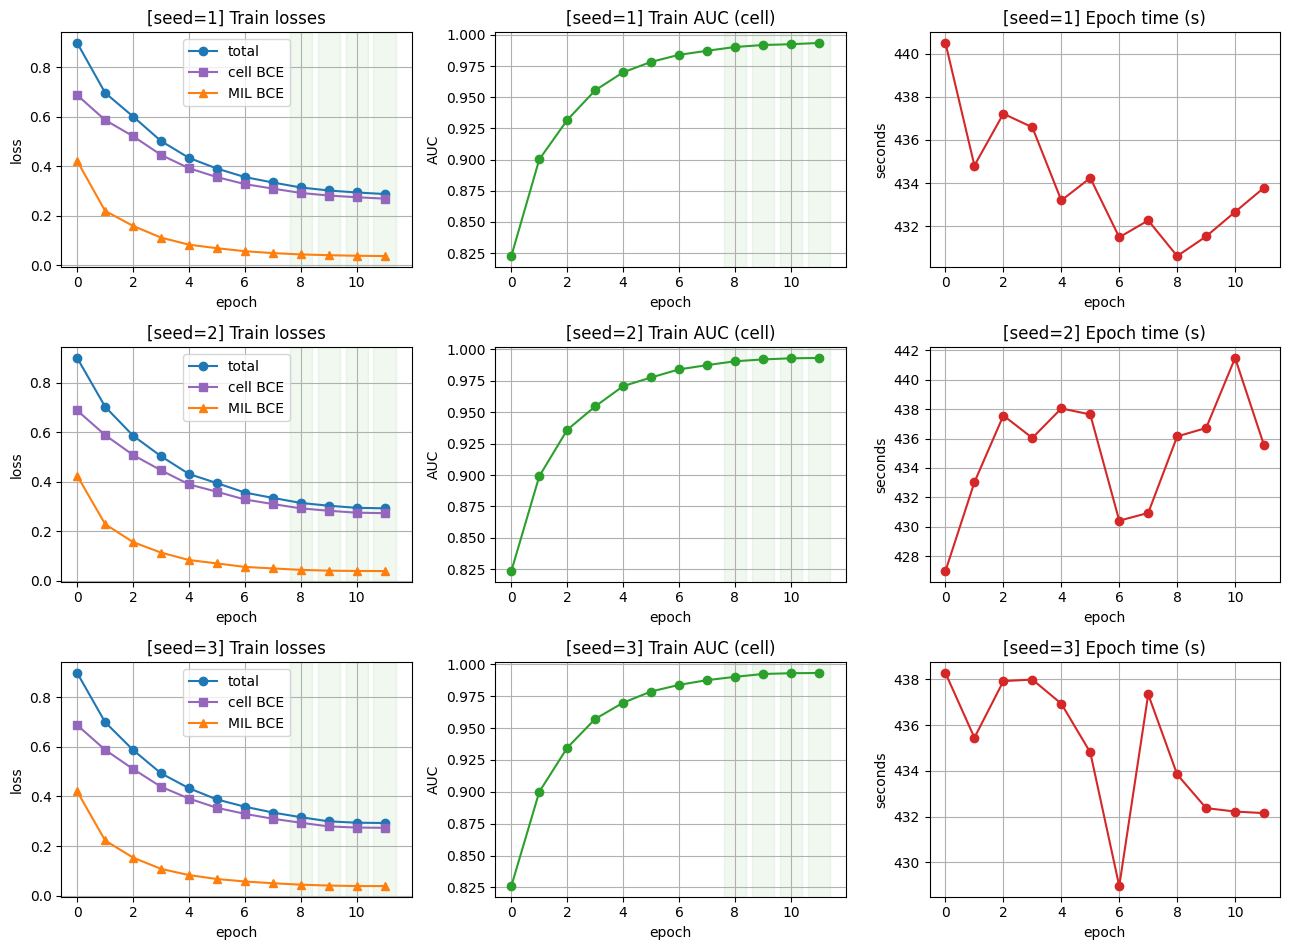

In [9]:
# Per-seed learning curves overlaid (loss, AUC, time).
n_seeds = len(trained_seeds)
fig, axes = plt.subplots(n_seeds, 3, figsize=(13, 3.2 * n_seeds), squeeze=False)
for row, t in enumerate(trained_seeds):
    seed = t["seed"]; h = t["history"]
    epochs = [e["epoch"] for e in h]
    ax_l, ax_a, ax_t = axes[row]
    ax_l.plot(epochs, [e["tr_loss"] for e in h], marker="o", color="tab:blue", label="total")
    ax_l.plot(epochs, [e["tr_cell"] for e in h], marker="s", color="tab:purple", label="cell BCE")
    ax_l.plot(epochs, [e["tr_mil"]  for e in h], marker="^", color="tab:orange", label="MIL BCE")
    # Mark SWA epochs
    for e in h:
        if e["swa_active"]:
            ax_l.axvspan(e["epoch"] - 0.4, e["epoch"] + 0.4, color="tab:green", alpha=0.07)
            ax_a.axvspan(e["epoch"] - 0.4, e["epoch"] + 0.4, color="tab:green", alpha=0.07)
    ax_l.legend(); ax_l.set(title=f"[seed={seed}] Train losses", xlabel="epoch", ylabel="loss"); ax_l.grid(True)
    ax_a.plot(epochs, [e["tr_auc"]  for e in h], marker="o", color="tab:green")
    ax_a.set(title=f"[seed={seed}] Train AUC (cell)", xlabel="epoch", ylabel="AUC"); ax_a.grid(True)
    ax_t.plot(epochs, [e["time"]    for e in h], marker="o", color="tab:red")
    ax_t.set(title=f"[seed={seed}] Epoch time (s)",  xlabel="epoch", ylabel="seconds"); ax_t.grid(True)
plt.tight_layout()
plt.savefig("/kaggle/working/learning_curves.png", dpi=120, bbox_inches="tight")
plt.show()

In [10]:
@torch.no_grad()
def adabn_pass(model, loader):
    model.train()
    for batch in loader:
        bf = batch["bf"].to(DEVICE, non_blocking=True)
        fl = batch["fl"].to(DEVICE, non_blocking=True)
        with torch.amp.autocast("cuda", enabled=DEVICE == "cuda"):
            _ = model(bf, fl)
    model.eval()

def _d4_at_scale(bf, fl, scale=None):
    if scale is not None and scale != bf.shape[-1]:
        bf = F.interpolate(bf, size=(scale, scale), mode="bilinear", align_corners=False)
        fl = F.interpolate(fl, size=(scale, scale), mode="bilinear", align_corners=False)
    for k in range(4):
        bfr = torch.rot90(bf, k, dims=(-2, -1))
        flr = torch.rot90(fl, k, dims=(-2, -1))
        yield bfr, flr
        yield TF.hflip(bfr), TF.hflip(flr)

def _multiscale_tta(bf, fl, scales):
    for s in scales:
        for bf_t, fl_t in _d4_at_scale(bf, fl, scale=s):
            yield bf_t, fl_t

def load_model(ckpt_path):
    state = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    args = state.get("args", {})
    dropout = float(args.get("dropout", DROPOUT))
    model = MultimodalClassifier(pretrained=False, dropout=dropout).to(DEVICE)
    model.load_state_dict(state["model"]); model.eval()
    return model

def predict_one(ckpt_path, loader, tta_scales=None):
    model = load_model(ckpt_path)
    if USE_ADABN:
        print("  running AdaBN pass on test...")
        t0 = time.time()
        adabn_pass(model, loader)
        print(f"    AdaBN done in {time.time()-t0:.1f}s")
    aug_fn = (lambda bf, fl: _multiscale_tta(bf, fl, tta_scales)) if tta_scales \
             else (lambda bf, fl: _d4_at_scale(bf, fl))
    n_aug = 8 * (len(tta_scales) if tta_scales else 1)
    preds = []
    with torch.no_grad():
        for batch in loader:
            bf = batch["bf"].to(DEVICE, non_blocking=True)
            fl = batch["fl"].to(DEVICE, non_blocking=True)
            p = None
            for bf_t, fl_t in aug_fn(bf, fl):
                with torch.amp.autocast("cuda", enabled=DEVICE == "cuda"):
                    pi = torch.sigmoid(model(bf_t, fl_t)).float()
                p = pi if p is None else p + pi
            preds.append((p / n_aug).cpu().numpy())
    del model
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return np.concatenate(preds)

# Shared test loader (use TEST cache only — no pseudo-label mixing at inference).
test_ds = CachedCellDataset(df_test, bf_test_cache, fl_test_cache,
                            eval_modality_transform("bf"),
                            eval_modality_transform("fl"))
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True)

scales_to_use = TTA_SCALES if USE_EXTENDED_TTA else (112, 128, 144)
n_aug_total = 8 * len(scales_to_use)
print(f"Predicting with {n_aug_total}-way TTA (scales={scales_to_use}, AdaBN={USE_ADABN})  "
      f"for {len(trained_seeds)} SWA seeds")

per_seed_preds = {}
for t in trained_seeds:
    seed = t["seed"]
    print(f"\n--- Predict [seed={seed}] ---")
    t0 = time.time()
    preds = predict_one(t["ckpt"], test_loader, tta_scales=scales_to_use)
    per_seed_preds[seed] = preds
    pm_path = WORK_DIR / f"submission_seed{seed}.csv"
    pd.DataFrame({"Name": df_test["Name"].values,
                  "Diagnosis": preds}).to_csv(pm_path, index=False)
    print(f"  [seed={seed}] done in {time.time()-t0:.1f}s  "
          f"mean={preds.mean():.4f}  <0.05={(preds<0.05).mean():.2%}  >0.95={(preds>0.95).mean():.2%}")

# Ensemble: sigmoid-average across all seeds (same-arch, same-recipe).
print(f"\n--- Building ensemble of {len(per_seed_preds)} seeds (sigmoid average) ---")
ensemble_preds = np.mean(list(per_seed_preds.values()), axis=0)
sub = pd.DataFrame({"Name": df_test["Name"].values, "Diagnosis": ensemble_preds})
sub.to_csv(WORK_DIR / "submission.csv", index=False)
print(f"Auto-submitted ensemble (sigmoid avg of {len(per_seed_preds)} seeds): "
      f"mean={ensemble_preds.mean():.4f}  min={ensemble_preds.min():.4f}  max={ensemble_preds.max():.4f}  "
      f"<0.05={(ensemble_preds<0.05).mean():.2%}  >0.95={(ensemble_preds>0.95).mean():.2%}")
print(sub.head())

# Summary of all CSVs written.
print(f"\n=== Output summary ===")
for f in sorted(WORK_DIR.glob("submission*.csv")):
    arr = pd.read_csv(f)["Diagnosis"].values
    print(f"  {f.name:>35}  rows={len(arr):>6}  mean={arr.mean():.4f}  std={arr.std():.4f}")
!wc -l /kaggle/working/submission*.csv

Predicting with 40-way TTA (scales=(96, 112, 128, 144, 160), AdaBN=True)  for 3 SWA seeds

--- Predict [seed=1] ---
  running AdaBN pass on test...
    AdaBN done in 48.9s
  [seed=1] done in 1432.3s  mean=0.5397  <0.05=5.94%  >0.95=14.87%

--- Predict [seed=2] ---
  running AdaBN pass on test...
    AdaBN done in 44.6s
  [seed=2] done in 1407.7s  mean=0.4082  <0.05=10.67%  >0.95=6.62%

--- Predict [seed=3] ---
  running AdaBN pass on test...
    AdaBN done in 45.2s
  [seed=3] done in 1411.1s  mean=0.4851  <0.05=7.08%  >0.95=11.35%

--- Building ensemble of 3 seeds (sigmoid average) ---
Auto-submitted ensemble (sigmoid avg of 3 seeds): mean=0.4777  min=0.0004  max=1.0000  <0.05=6.66%  >0.95=9.27%
          Name  Diagnosis
0  image_1.jpg   0.698349
1  image_2.jpg   0.577898
2  image_3.jpg   0.789740
3  image_4.jpg   0.293382
4  image_5.jpg   0.127957

=== Output summary ===
                       submission.csv  rows= 59040  mean=0.4777  std=0.3188
                 submission_seed1.csv  